In [1]:
import sys, os
# Agregar src/ al path para importar modulos del proyecto
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib

from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics         import classification_report, roc_auc_score

from src.data_loader         import load_raw_data, basic_profiling
from src.feature_engineering import build_viralidad, build_features, get_feature_columns
from src.preprocessing       import build_preprocessor, split_data, save_preprocessor

# IMPORTACIONES ACTUALIZADAS
from src.modeling            import get_base_models, tune_hyperparameters, cross_validate_models, train_and_save
from src.evaluation          import (
    evaluate_on_test, plot_confusion_matrices, plot_roc_curves,
    plot_feature_importance, plot_cv_comparison, plot_metrics_heatmap, save_tuning_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
SAMPLE_SIZE  = 100_000
RAW_PATH     = '../data/raw/global_youtube_creator_data_large.csv'
FIGURES_DIR  = '../reports/figures'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
# FASE 2 | Comprensión de los datos
---

## 2.1 Carga de datos

In [2]:
df_raw = load_raw_data(RAW_PATH, sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
basic_profiling(df_raw)

[INFO] Cargando datos desde: ../data/raw/global_youtube_creator_data_large.csv
[INFO] Dataset completo: 1,000,000 filas x 12 columnas
[INFO] Muestra extraida: 100,000 filas

PERFIL BASICO DEL DATASET

Dimensiones  : 100,000 filas x 12 columnas

Tipos de dato:
timestamp           object
video_id            object
category            object
language            object
region              object
duration_sec         int64
views                int64
likes                int64
comments             int64
shares               int64
sentiment_score    float64
ads_enabled           bool
dtype: object

Valores nulos:
timestamp          0
video_id           0
category           0
language           0
region             0
duration_sec       0
views              0
likes              0
comments           0
shares             0
sentiment_score    0
ads_enabled        0
dtype: int64

Duplicados   : 0

Estadisticas descriptivas:
                    count unique                  top   freq         mean  

## 2.2 Descripción de variables

| Variable        | Tipo        | Descripción                                         |
|-----------------|-------------|-----------------------------------------------------|
| timestamp       | datetime    | Fecha y hora de publicacion del video               |
| video_id        | categorica  | Identificador unico del video                       |
| category        | categorica  | Categoria del contenido (6 categorias)              |
| language        | categorica  | Idioma del video (5 idiomas)                        |
| region          | categorica  | Region de origen (5 regiones)                       |
| duration_sec    | numerica    | Duracion del video en segundos [60, 3600]           |
| views           | numerica    | Numero total de visualizaciones                     |
| likes           | numerica    | Numero total de likes                               |
| comments        | numerica    | Numero total de comentarios                         |
| shares          | numerica    | Numero total de compartidos                         |
| sentiment_score | numerica    | Puntaje de sentimiento de comentarios [-1, 1]       |
| ads_enabled     | binaria     | Si el video tiene publicidad habilitada (True/False) |

## 2.3 Análisis de valores nulos y calidad

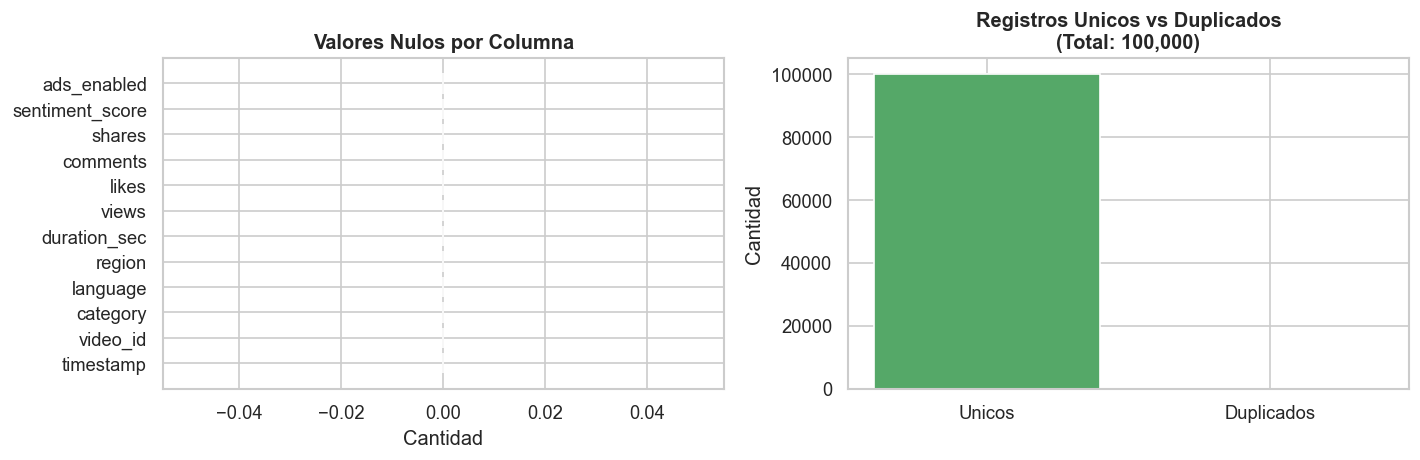

Valores nulos: 0 | Duplicados: 0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Nulos
nulls = df_raw.isnull().sum()
axes[0].barh(nulls.index, nulls.values, color='#C44E52')
axes[0].set_title('Valores Nulos por Columna', fontweight='bold')
axes[0].set_xlabel('Cantidad')

# Duplicados
n_dup = df_raw.duplicated().sum()
axes[1].bar(['Unicos', 'Duplicados'], [len(df_raw) - n_dup, n_dup],
             color=['#55A868', '#C44E52'])
axes[1].set_title(f'Registros Unicos vs Duplicados\n(Total: {len(df_raw):,})', fontweight='bold')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/calidad_datos.png', bbox_inches='tight')
plt.show()
print(f'Valores nulos: {nulls.sum()} | Duplicados: {n_dup}')

## 2.3b Detección de Outliers e Inconsistencias

Se aplica el método **IQR (rango intercuartílico)** para identificar valores extremos.
Un valor se considera outlier si está fuera de `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.
También se cuantifican registros con valor cero, que pueden enmascarar datos faltantes.

       Variable    Media  Mediana     IQR  Lim. inferior  Lim. superior  Outliers n  Outliers %  Ceros n
   duration_sec  1830.10   1834.0  1776.0       -1722.00        5382.00           0        0.00        0
          views 10047.12   6997.0 11007.0      -13606.50       30421.50        4740        4.74       11
          likes   551.63    323.0   611.0        -795.50        1648.50        6655        6.66      243
       comments    68.71     37.0    75.0         -99.50         200.50        7479        7.48     2421
         shares    29.66     18.0    33.0         -42.50          89.50        6051        6.05     3838
sentiment_score     0.00      0.0     1.0          -1.99           1.99           0        0.00       54


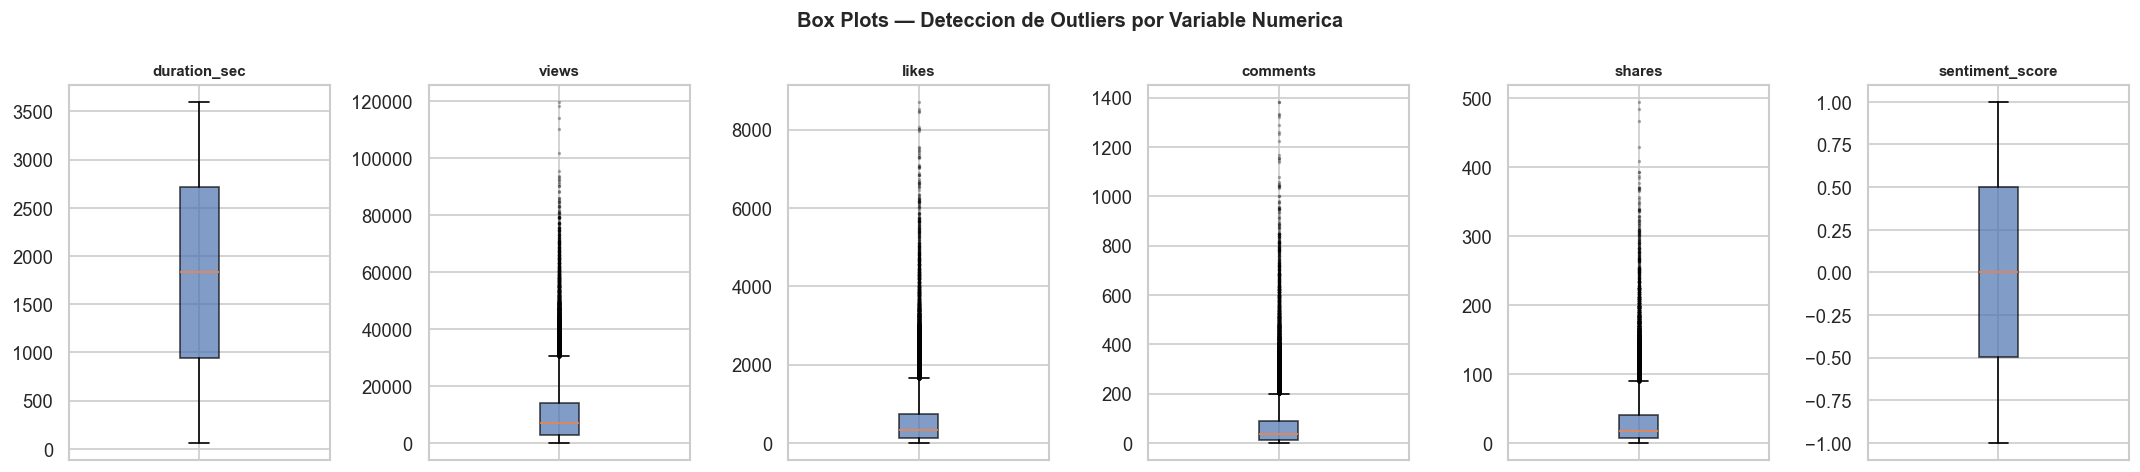


Variables con mayor proporcion de outliers:
       Variable  Outliers %  Ceros n
       comments        7.48     2421
          likes        6.66      243
         shares        6.05     3838
          views        4.74       11
   duration_sec        0.00        0
sentiment_score        0.00       54


In [4]:
num_cols_all = ['duration_sec', 'views', 'likes', 'comments', 'shares', 'sentiment_score']

outlier_report = []
for col in num_cols_all:
    Q1, Q3 = df_raw[col].quantile(0.25), df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out   = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    n_zeros = (df_raw[col] == 0).sum()
    outlier_report.append({
        'Variable': col, 'Media': round(df_raw[col].mean(), 2),
        'Mediana': round(df_raw[col].median(), 2), 'IQR': round(IQR, 2),
        'Lim. inferior': round(lower, 2), 'Lim. superior': round(upper, 2),
        'Outliers n': n_out, 'Outliers %': round(100 * n_out / len(df_raw), 2),
        'Ceros n': n_zeros,
    })

df_outliers = pd.DataFrame(outlier_report)
print(df_outliers.to_string(index=False))

fig, axes = plt.subplots(1, len(num_cols_all), figsize=(18, 4))
for ax, col in zip(axes, num_cols_all):
    bp = ax.boxplot(df_raw[col].dropna(), patch_artist=True,
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    bp['boxes'][0].set_facecolor('#4C72B0'); bp['boxes'][0].set_alpha(0.7)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelbottom=False)

plt.suptitle('Box Plots — Deteccion de Outliers por Variable Numerica', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/outliers_boxplot.png', bbox_inches='tight')
plt.show()
print('\nVariables con mayor proporcion de outliers:')
print(df_outliers[['Variable','Outliers %','Ceros n']].sort_values('Outliers %', ascending=False).to_string(index=False))

## 2.4 Distribución de variables numericas de engagement

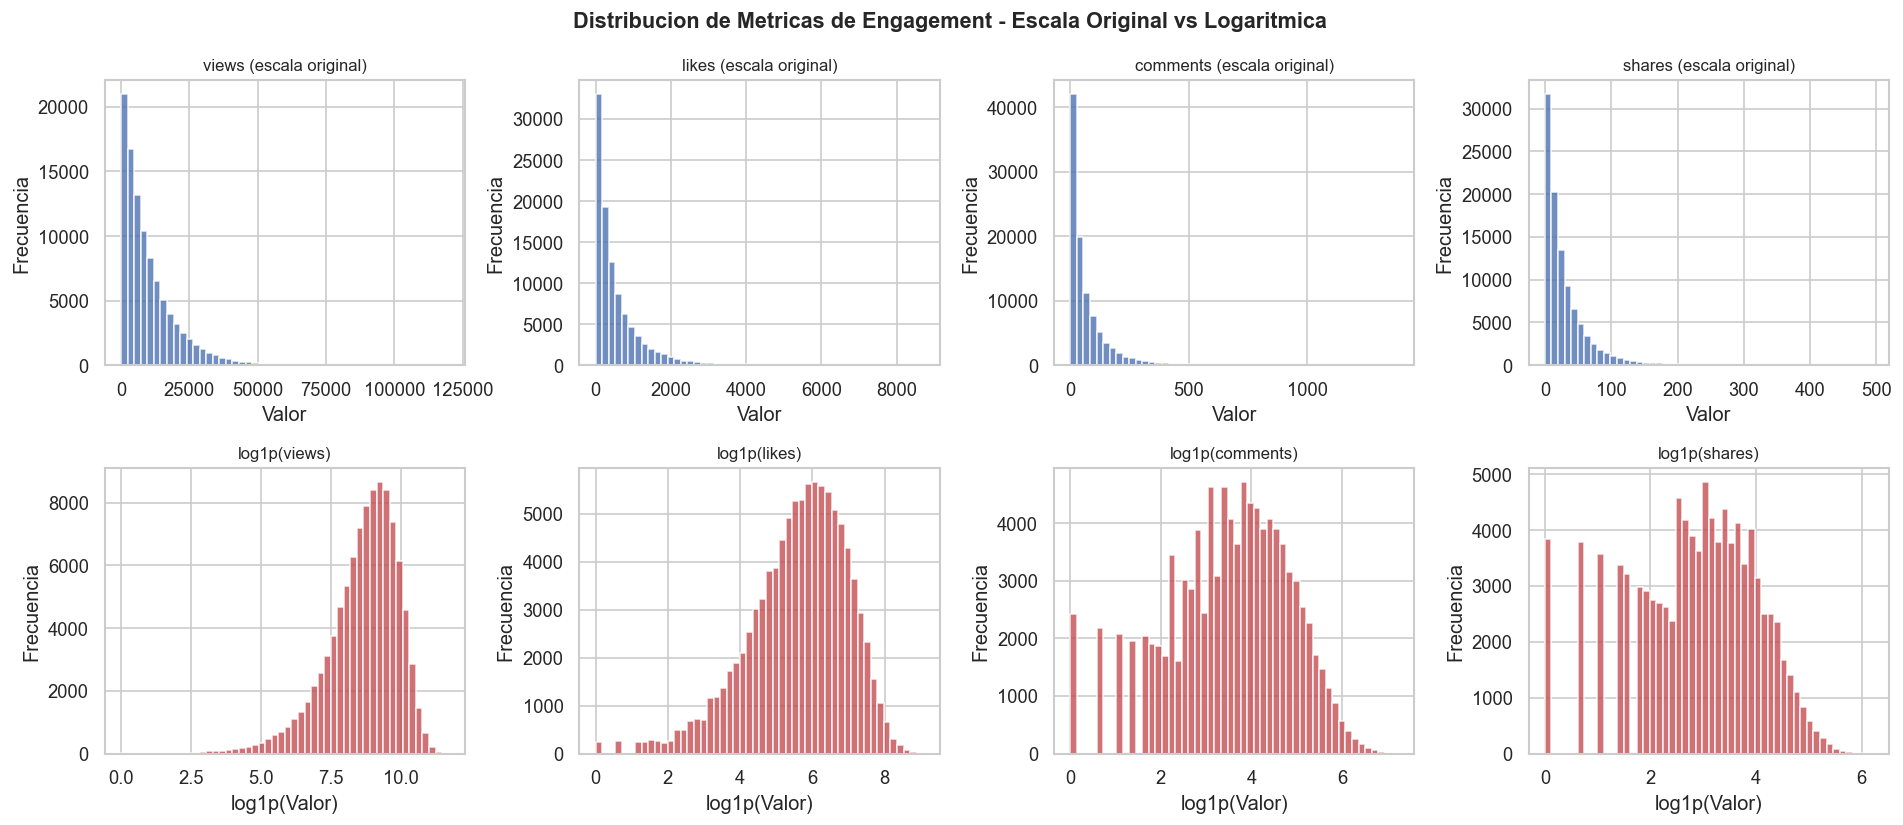


Observacion: Las metricas siguen una distribucion de cola larga (tipo ley de potencia).
La transformacion log1p simetriza la distribucion, lo cual es crucial para la
construccion del puntaje de viralidad y para el rendimiento de la regresion logistica.


In [5]:
engagement_cols = ['views', 'likes', 'comments', 'shares']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, col in enumerate(engagement_cols):
    # Escala original
    axes[0, i].hist(df_raw[col], bins=50, color='#4C72B0', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{col} (escala original)', fontsize=10)
    axes[0, i].set_xlabel('Valor')
    axes[0, i].set_ylabel('Frecuencia')

    # Escala log
    axes[1, i].hist(np.log1p(df_raw[col]), bins=50, color='#C44E52', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'log1p({col})', fontsize=10)
    axes[1, i].set_xlabel('log1p(Valor)')
    axes[1, i].set_ylabel('Frecuencia')

fig.suptitle('Distribucion de Metricas de Engagement - Escala Original vs Logaritmica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/distribucion_engagement.png', bbox_inches='tight')
plt.show()

print('\nObservacion: Las metricas siguen una distribucion de cola larga (tipo ley de potencia).')
print('La transformacion log1p simetriza la distribucion, lo cual es crucial para la')
print('construccion del puntaje de viralidad y para el rendimiento de la regresion logistica.')

## 2.4b Estadísticas Univariadas Avanzadas

Se calcula el **coeficiente de variación (CV)**, la **asimetría (skewness)** y la
**curtosis** para caracterizar la forma de cada distribución.
Estos valores justifican la transformación logarítmica aplicada en fases posteriores.

Estadisticas descriptivas avanzadas:
       Variable     Media  Mediana       Std  CV (%)  Asimetria  Curtosis    p10       p90
   duration_sec  1830.095 1834.000  1022.857    55.9      0.000    -1.206  413.0  3246.000
          views 10047.116 6997.000 10011.230    99.6      2.013     6.182 1069.0 23125.100
          likes   551.633  323.000   664.172   120.4      2.770    12.407   42.0  1350.000
       comments    68.711   37.000    91.171   132.7      3.248    17.410    4.0   171.000
         shares    29.658   18.000    34.346   115.8      2.623    11.180    2.0    71.000
sentiment_score     0.001    0.002     0.576 63845.1     -0.003    -1.193   -0.8     0.799


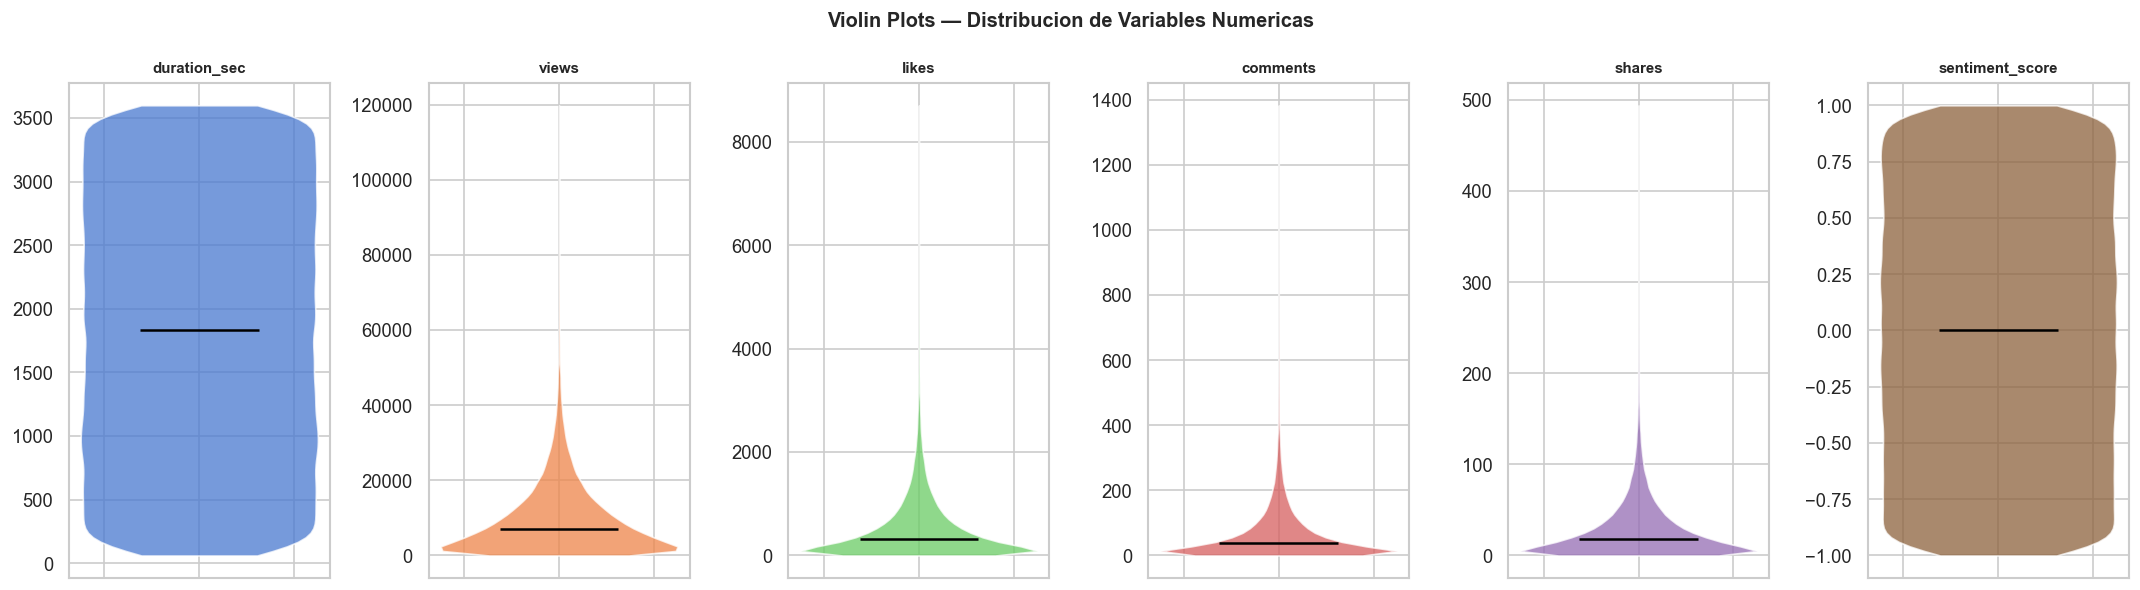


Asimetria > 1: cola derecha pronunciada. Curtosis > 0: colas pesadas (valores extremos frecuentes).


In [6]:
from scipy import stats as scipy_stats

stats_report = []
for col in num_cols_all:
    s = df_raw[col]
    stats_report.append({
        'Variable': col,
        'Media':     round(s.mean(), 3),
        'Mediana':   round(s.median(), 3),
        'Std':       round(s.std(), 3),
        'CV (%)':    round(100 * s.std() / abs(s.mean()), 1) if s.mean() != 0 else float('nan'),
        'Asimetria': round(scipy_stats.skew(s.dropna()), 3),
        'Curtosis':  round(scipy_stats.kurtosis(s.dropna()), 3),
        'p10':       round(s.quantile(0.10), 3),
        'p90':       round(s.quantile(0.90), 3),
    })

df_stats = pd.DataFrame(stats_report)
print('Estadisticas descriptivas avanzadas:')
print(df_stats.to_string(index=False))

fig, axes = plt.subplots(1, len(num_cols_all), figsize=(18, 5))
palette_v = sns.color_palette('muted', len(num_cols_all))
for ax, col, color in zip(axes, num_cols_all, palette_v):
    parts = ax.violinplot(df_raw[col].dropna(), showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color); pc.set_alpha(0.75)
    parts['cmedians'].set_color('black')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelbottom=False)

plt.suptitle('Violin Plots — Distribucion de Variables Numericas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/violin_numericas.png', bbox_inches='tight')
plt.show()
print('\nAsimetria > 1: cola derecha pronunciada. Curtosis > 0: colas pesadas (valores extremos frecuentes).')

## 2.5 Análisis de variables categóricas

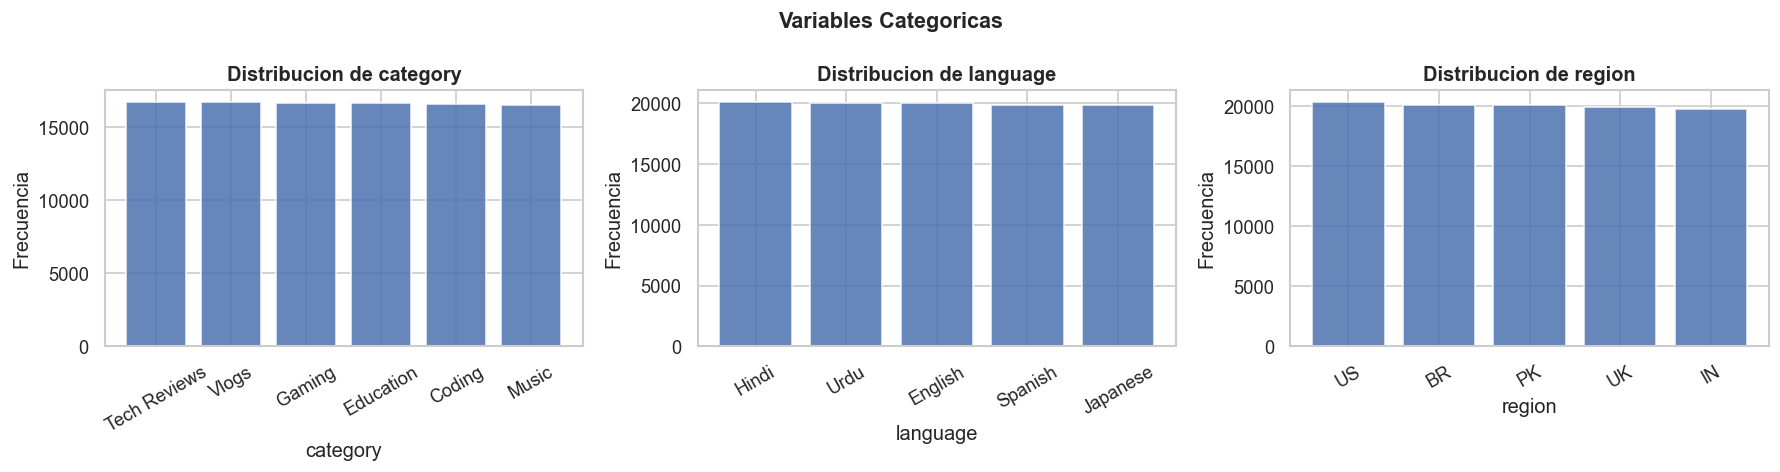

In [7]:
cat_cols = ['category', 'language', 'region']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, cat_cols):
    counts = df_raw[col].value_counts()
    ax.bar(counts.index, counts.values, color='#4C72B0', alpha=0.85)
    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Variables Categoricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/distribucion_categoricas.png', bbox_inches='tight')
plt.show()

## 2.5b Análisis Temporal

Se extraen componentes del campo `timestamp` (hora, día de semana, mes)
para detectar patrones de publicación y su efecto sobre el engagement.
Estos patrones son candidatos directos a variables de entrada para los modelos.

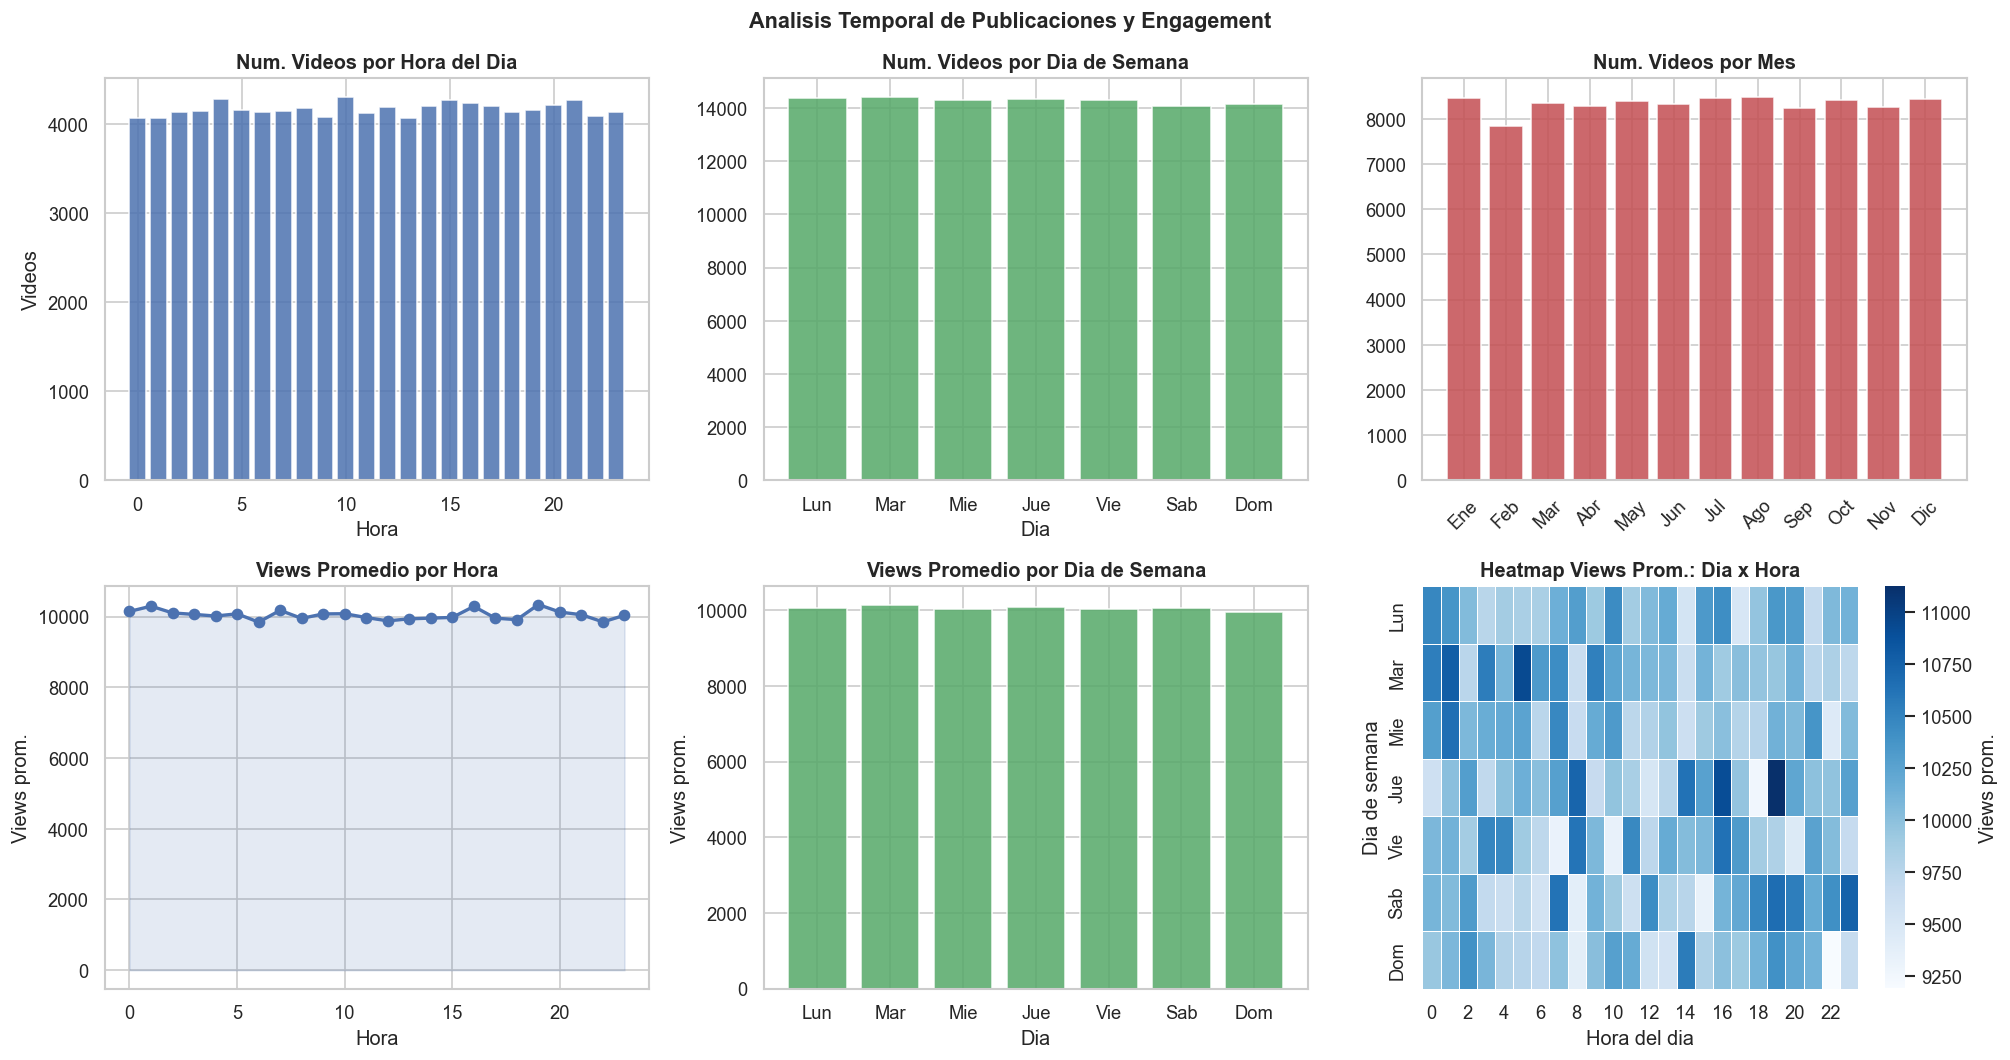

Hora pico de publicacion: 10 h
Dia con mas publicaciones: Mar
Hora con mayor views promedio: 19 h


In [8]:
df_temp = df_raw.copy()
df_temp['timestamp'] = pd.to_datetime(df_temp['timestamp'])
df_temp['hora']       = df_temp['timestamp'].dt.hour
df_temp['dia_semana'] = df_temp['timestamp'].dt.dayofweek
df_temp['mes']        = df_temp['timestamp'].dt.month

dias_es  = ['Lun','Mar','Mie','Jue','Vie','Sab','Dom']
meses_es = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

hora_cnt = df_temp.groupby('hora').size()
axes[0,0].bar(hora_cnt.index, hora_cnt.values, color='#4C72B0', alpha=0.85)
axes[0,0].set_title('Num. Videos por Hora del Dia', fontweight='bold')
axes[0,0].set_xlabel('Hora'); axes[0,0].set_ylabel('Videos')

dia_cnt = df_temp.groupby('dia_semana').size().reindex(range(7), fill_value=0)
axes[0,1].bar(dias_es, dia_cnt.values, color='#55A868', alpha=0.85)
axes[0,1].set_title('Num. Videos por Dia de Semana', fontweight='bold')
axes[0,1].set_xlabel('Dia')

mes_cnt = df_temp.groupby('mes').size().reindex(range(1,13), fill_value=0)
axes[0,2].bar([meses_es[m-1] for m in mes_cnt.index], mes_cnt.values, color='#C44E52', alpha=0.85)
axes[0,2].set_title('Num. Videos por Mes', fontweight='bold')
axes[0,2].tick_params(axis='x', rotation=45)

views_hora = df_temp.groupby('hora')['views'].mean()
axes[1,0].plot(views_hora.index, views_hora.values, marker='o', color='#4C72B0', lw=2)
axes[1,0].fill_between(views_hora.index, views_hora.values, alpha=0.15, color='#4C72B0')
axes[1,0].set_title('Views Promedio por Hora', fontweight='bold')
axes[1,0].set_xlabel('Hora'); axes[1,0].set_ylabel('Views prom.')

views_dia = df_temp.groupby('dia_semana')['views'].mean().reindex(range(7), fill_value=0)
axes[1,1].bar(dias_es, views_dia.values, color='#55A868', alpha=0.85)
axes[1,1].set_title('Views Promedio por Dia de Semana', fontweight='bold')
axes[1,1].set_xlabel('Dia'); axes[1,1].set_ylabel('Views prom.')

pivot = df_temp.pivot_table(values='views', index='dia_semana', columns='hora', aggfunc='mean')
pivot.index = dias_es
sns.heatmap(pivot, ax=axes[1,2], cmap='Blues', linewidths=0.3, cbar_kws={'label': 'Views prom.'})
axes[1,2].set_title('Heatmap Views Prom.: Dia x Hora', fontweight='bold')
axes[1,2].set_xlabel('Hora del dia'); axes[1,2].set_ylabel('Dia de semana')

plt.suptitle('Analisis Temporal de Publicaciones y Engagement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/analisis_temporal.png', bbox_inches='tight')
plt.show()
print('Hora pico de publicacion:', hora_cnt.idxmax(), 'h')
print('Dia con mas publicaciones:', dias_es[dia_cnt.idxmax()])
print('Hora con mayor views promedio:', views_hora.idxmax(), 'h')

## 2.6 Matriz de correlación


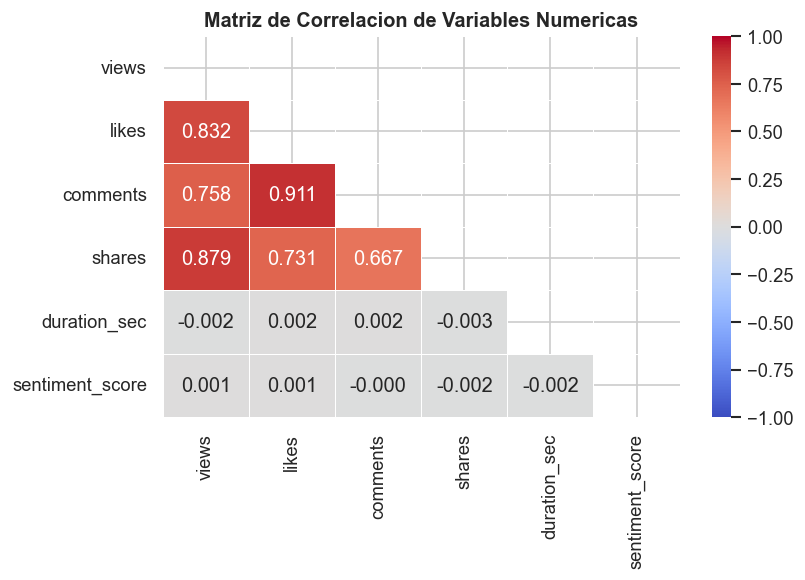


Hallazgos clave:
  - Correlacion views-likes    : 0.832
  - Correlacion views-comments : 0.758
  - Correlacion views-shares   : 0.879
  - Correlacion likes-comments : 0.911


In [9]:
num_cols = ['views', 'likes', 'comments', 'shares', 'duration_sec', 'sentiment_score']
corr = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlacion de Variables Numericas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/correlacion.png', bbox_inches='tight')
plt.show()

print('\nHallazgos clave:')
print(f'  - Correlacion views-likes    : {corr.loc["views","likes"]:.3f}')
print(f'  - Correlacion views-comments : {corr.loc["views","comments"]:.3f}')
print(f'  - Correlacion views-shares   : {corr.loc["views","shares"]:.3f}')
print(f'  - Correlacion likes-comments : {corr.loc["likes","comments"]:.3f}')

## 2.6b Análisis Bivariado — Relaciones entre Variables Numéricas

Scatter plots entre pares de métricas en escala log, coloreados por categoría.
El coeficiente de Pearson (`r`) cuantifica la linealidad de cada relación.

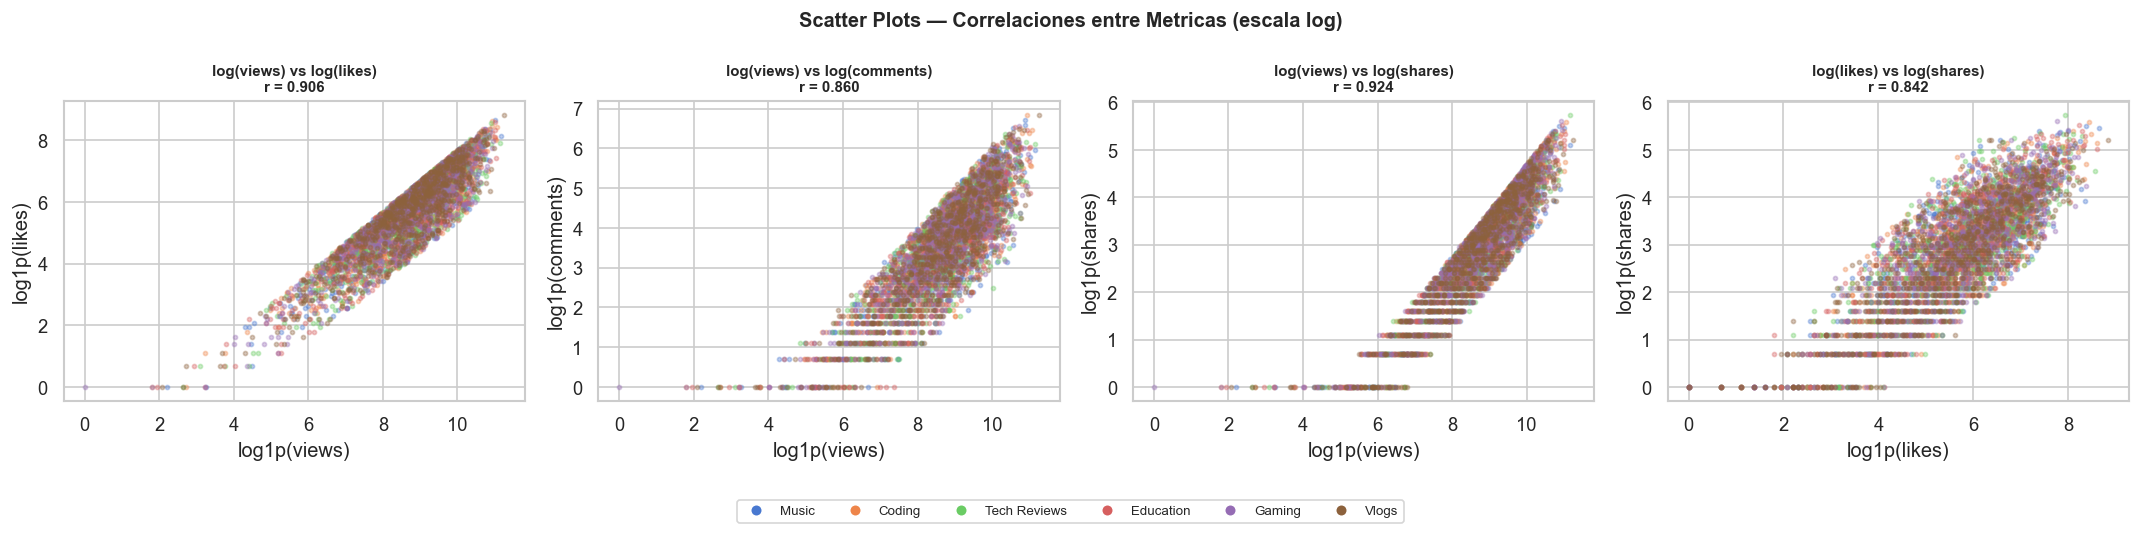

Correlaciones de Pearson (escala log):
  log(views) vs log(likes):  r=0.9057  p=0.00e+00
  log(views) vs log(comments):  r=0.8605  p=0.00e+00
  log(views) vs log(shares):  r=0.9236  p=0.00e+00
  log(likes) vs log(shares):  r=0.8421  p=0.00e+00


In [10]:
from scipy import stats as scipy_stats

pairs     = [('views','likes'), ('views','comments'), ('views','shares'), ('likes','shares')]
cats_uniq = df_raw['category'].unique()
palette_s = dict(zip(cats_uniq, sns.color_palette('muted', len(cats_uniq))))
sample_sc = df_raw.sample(5_000, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (x, y) in zip(axes, pairs):
    for cat in cats_uniq:
        mask = sample_sc['category'] == cat
        ax.scatter(np.log1p(sample_sc.loc[mask, x]),
                   np.log1p(sample_sc.loc[mask, y]),
                   s=6, alpha=0.35, color=palette_s[cat], label=cat)
    r, _ = scipy_stats.pearsonr(np.log1p(df_raw[x]), np.log1p(df_raw[y]))
    ax.set_title(f'log({x}) vs log({y})\nr = {r:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel(f'log1p({x})'); ax.set_ylabel(f'log1p({y})')

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=palette_s[c], markersize=7, label=c) for c in cats_uniq]
fig.legend(handles=handles, loc='lower center', ncol=len(cats_uniq),
           fontsize=8, bbox_to_anchor=(0.5, -0.1))
plt.suptitle('Scatter Plots — Correlaciones entre Metricas (escala log)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/scatter_bivariado.png', bbox_inches='tight')
plt.show()

print('Correlaciones de Pearson (escala log):')
for x, y in pairs:
    r, p = scipy_stats.pearsonr(np.log1p(df_raw[x]), np.log1p(df_raw[y]))
    print(f'  log({x}) vs log({y}):  r={r:.4f}  p={p:.2e}')

### 2.6c Análisis Bivariado — Variables Categóricas vs Engagement

Box plots de `views` (escala log) por `category`, `language` y `region`,
ordenados por mediana. El heatmap cruza `category × region`.

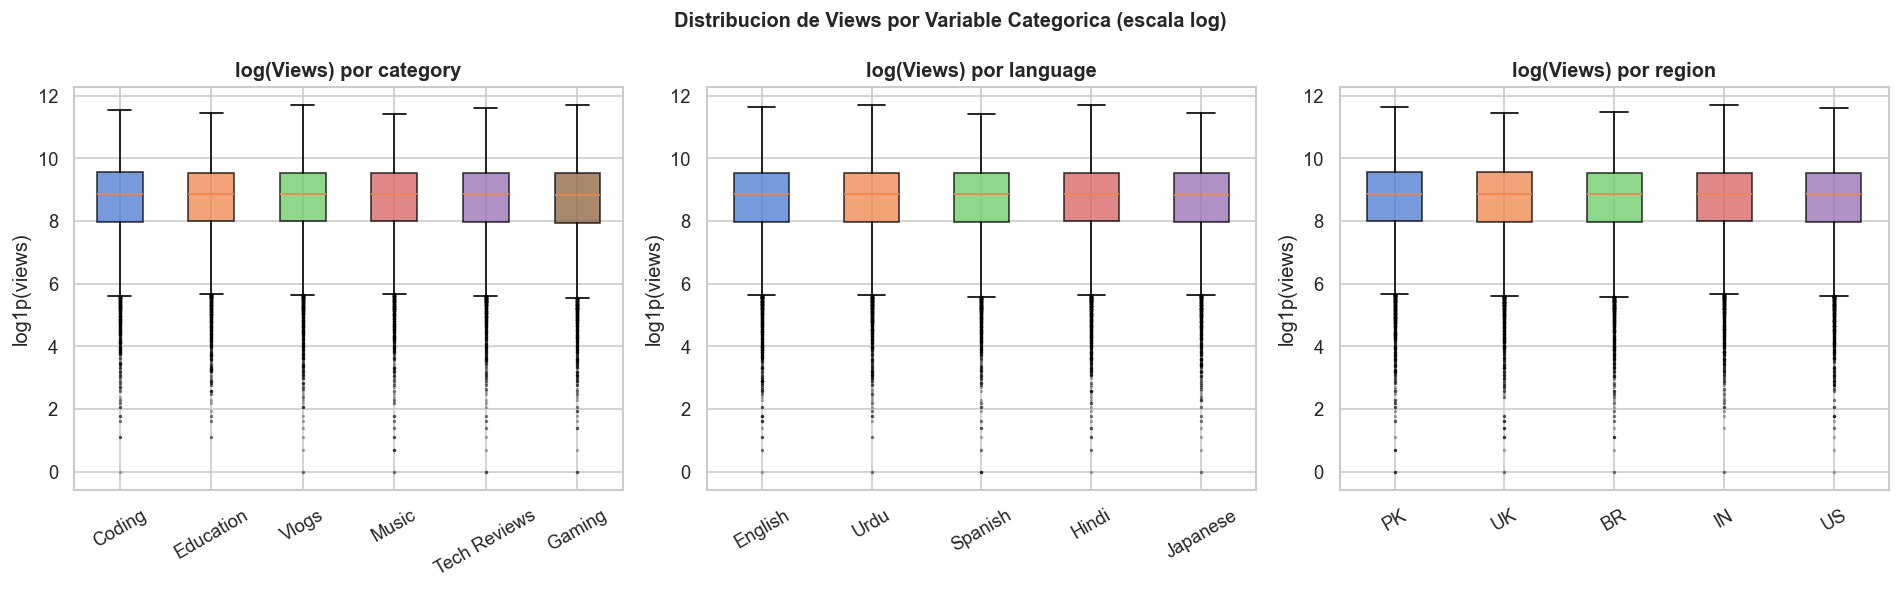

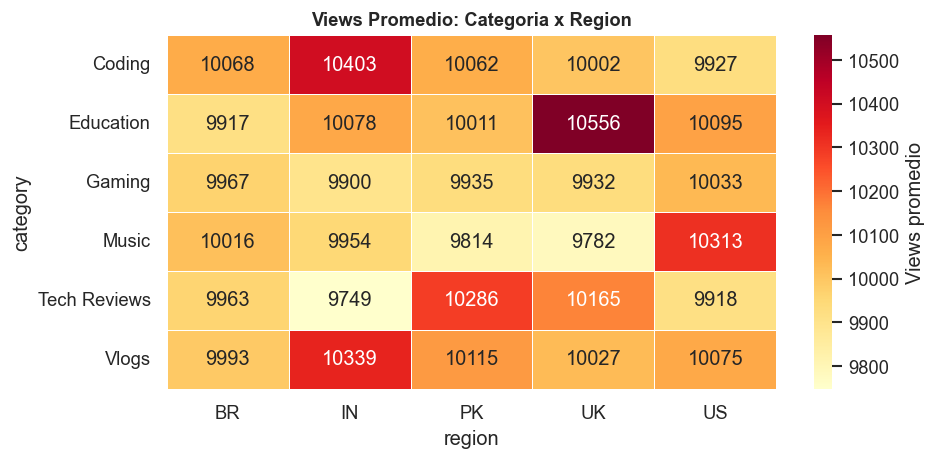

Views promedio por categoria:
category
Education       10131.0
Vlogs           10111.1
Coding          10090.3
Tech Reviews    10017.7
Music            9978.1
Gaming           9954.1


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cat in zip(axes, ['category', 'language', 'region']):
    orden  = df_raw.groupby(cat)['views'].median().sort_values(ascending=False).index
    groups = [np.log1p(df_raw[df_raw[cat] == v]['views'].values) for v in orden]
    bp = ax.boxplot(groups, labels=orden, patch_artist=True,
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    cols_bp = sns.color_palette('muted', len(orden))
    for patch, color in zip(bp['boxes'], cols_bp):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(f'log(Views) por {cat}', fontweight='bold')
    ax.set_ylabel('log1p(views)'); ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribucion de Views por Variable Categorica (escala log)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/views_por_categorica.png', bbox_inches='tight')
plt.show()

pivot_cr = df_raw.pivot_table(values='views', index='category', columns='region', aggfunc='mean')
fig, ax  = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot_cr, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Views promedio'})
ax.set_title('Views Promedio: Categoria x Region', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/heatmap_categoria_region.png', bbox_inches='tight')
plt.show()

print('Views promedio por categoria:')
print(df_raw.groupby('category')['views'].mean().sort_values(ascending=False).round(1).to_string())

## 2.7 Engagement promedio por categoría

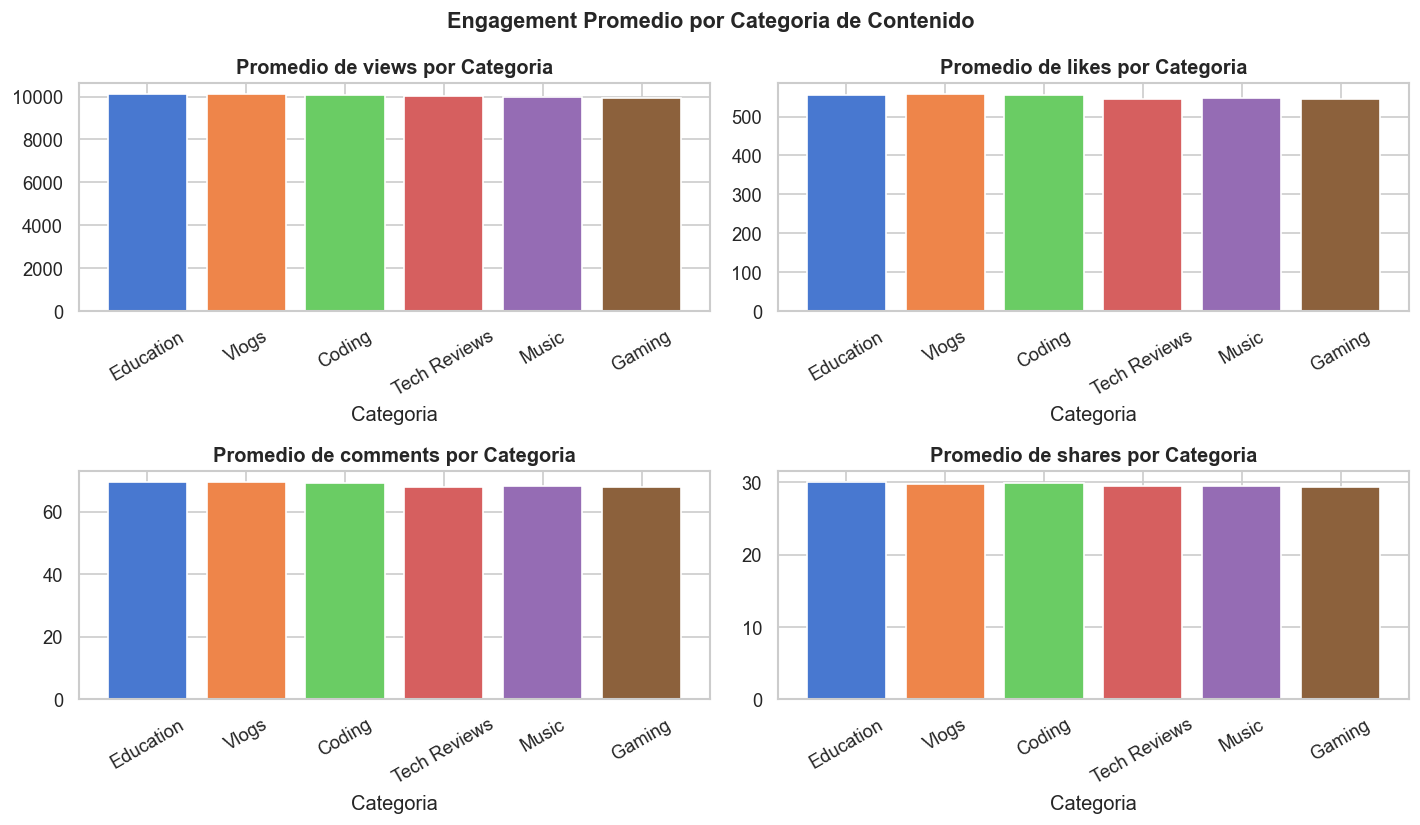

In [12]:
engagement_by_cat = df_raw.groupby('category')[engagement_cols].mean().sort_values('views', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
colors = sns.color_palette('muted', len(engagement_by_cat))

for ax, col in zip(axes.flat, engagement_cols):
    bars = ax.bar(engagement_by_cat.index, engagement_by_cat[col], color=colors)
    ax.set_title(f'Promedio de {col} por Categoria', fontweight='bold')
    ax.set_xlabel('Categoria')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Engagement Promedio por Categoria de Contenido', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/engagement_por_categoria.png', bbox_inches='tight')
plt.show()

## 2.7b Análisis de Sentiment Score y Publicidad

Se analiza `sentiment_score` (rango [-1, 1]) de forma global y por categoría.
También se compara el engagement entre videos con y sin `ads_enabled`.

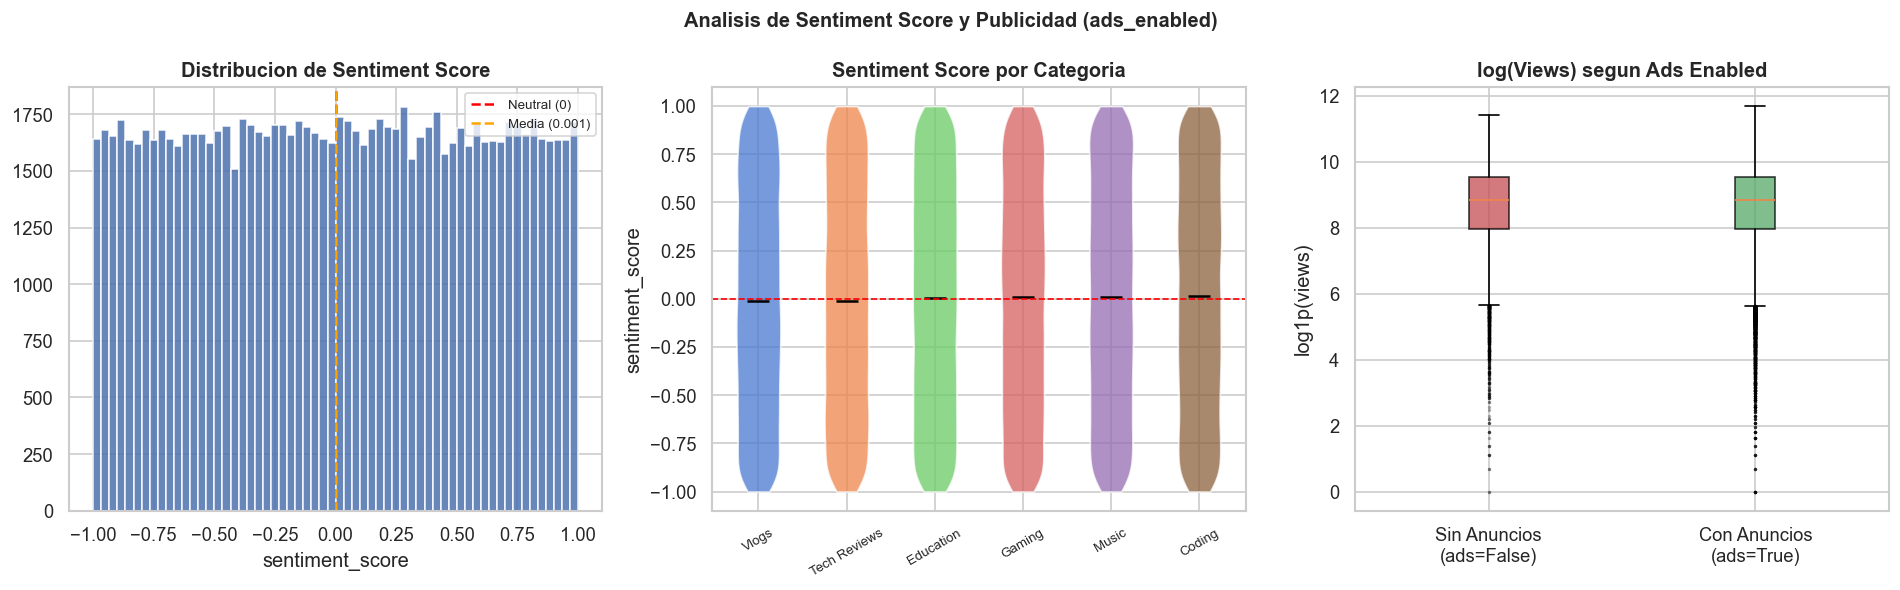

Sentiment promedio por categoria:
                mean     std  median
category                            
Coding        0.0107  0.5800   0.016
Education    -0.0031  0.5766   0.002
Gaming       -0.0005  0.5746   0.007
Music         0.0081  0.5776   0.010
Tech Reviews -0.0034  0.5751  -0.010
Vlogs        -0.0063  0.5745  -0.012

Engagement promedio segun ads_enabled:
               views  likes  comments  shares
ads_enabled                                  
False         9961.3  543.7      68.0    29.3
True         10068.8  553.6      68.9    29.8


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df_raw['sentiment_score'], bins=60, color='#4C72B0', alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', lw=1.5, label='Neutral (0)')
axes[0].axvline(df_raw['sentiment_score'].mean(), color='orange', linestyle='--', lw=1.5,
                label=f'Media ({df_raw["sentiment_score"].mean():.3f})')
axes[0].set_title('Distribucion de Sentiment Score', fontweight='bold')
axes[0].set_xlabel('sentiment_score'); axes[0].legend(fontsize=8)

cat_order_s = df_raw.groupby('category')['sentiment_score'].median().sort_values().index
data_viol   = [df_raw[df_raw['category'] == c]['sentiment_score'].values for c in cat_order_s]
parts = axes[1].violinplot(data_viol, showmedians=True, showextrema=False)
cols_v = sns.color_palette('muted', len(cat_order_s))
for pc, color in zip(parts['bodies'], cols_v):
    pc.set_facecolor(color); pc.set_alpha(0.75)
parts['cmedians'].set_color('black')
axes[1].set_xticks(range(1, len(cat_order_s) + 1))
axes[1].set_xticklabels(cat_order_s, rotation=30, fontsize=8)
axes[1].axhline(0, color='red', linestyle='--', lw=1)
axes[1].set_title('Sentiment Score por Categoria', fontweight='bold')
axes[1].set_ylabel('sentiment_score')

groups_ads = [np.log1p(df_raw[df_raw['ads_enabled'] == v]['views'].values) for v in [False, True]]
bp = axes[2].boxplot(groups_ads, labels=['Sin Anuncios\n(ads=False)', 'Con Anuncios\n(ads=True)'],
                     patch_artist=True, flierprops=dict(marker='.', markersize=2, alpha=0.3))
bp['boxes'][0].set_facecolor('#C44E52'); bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_facecolor('#55A868'); bp['boxes'][1].set_alpha(0.75)
axes[2].set_title('log(Views) segun Ads Enabled', fontweight='bold')
axes[2].set_ylabel('log1p(views)')

plt.suptitle('Analisis de Sentiment Score y Publicidad (ads_enabled)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/sentiment_ads_analisis.png', bbox_inches='tight')
plt.show()

print('Sentiment promedio por categoria:')
print(df_raw.groupby('category')['sentiment_score'].agg(['mean','std','median']).round(4).to_string())
print('\nEngagement promedio segun ads_enabled:')
print(df_raw.groupby('ads_enabled')[['views','likes','comments','shares']].mean().round(1).to_string())

In [14]:
import pickle, os

os.makedirs('../data/processed', exist_ok=True)

with open('../data/processed/df_raw.pkl', 'wb') as f:
    pickle.dump(df_raw, f)

print(f" df_raw guardado: {df_raw.shape}")

 df_raw guardado: (100000, 12)
